# Preprocesamiento de imágenes Chákṣu

Este notebook implementa y valida el pipeline geométrico de preprocesamiento
que será utilizado posteriormente por los modelos ResNet50V2 y EfficientNetV2-M.

Pipeline definido:

1. Lectura de la imagen en RGB.
2. Detección automática del campo de visión retinal.
3. Eliminación del contenido exterior mediante máscara.
4. Recorte del FOV con margen de seguridad.
5. Padding cuadrado preservando la relación de aspecto.
6. Redimensionamiento a 384 × 384 píxeles.

La validación visual del pipeline se realiza únicamente con imágenes de Train.

En esta etapa no se aplica Data Augmentation ni el preprocesamiento específico
de cada arquitectura.

## 1. Importaciones y configuración

Importación de librerías para manejo de rutas, visión computacional con OpenCV, manipulación de arreglos numéricos, análisis de metadatos tabulares y visualización.
Definición de las rutas del proyecto y carga del archivo de particiones congeladas `chaksu_splits.csv`.

In [1]:
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

PROJECT_ROOT = Path(r"C:\Users\SeuNg720\Documents\TP1-RetiScan")
CHAKSU_ROOT = (
    PROJECT_ROOT
    / "datasets"
    / "glaucoma"
    / "chaksu"
)
METADATA_DIR = CHAKSU_ROOT / "metadata"
SPLITS_PATH = (
    METADATA_DIR
    / "chaksu_splits.csv"
)
df = pd.read_csv(SPLITS_PATH)
print("Total:", len(df))
print(df["experimental_split"].value_counts())


Total: 1345
experimental_split
train         807
test          336
validation    202
Name: count, dtype: int64


## 2. Funciones de resolución y detección del campo de visión (FOV)

Se integran las funciones validadas en el notebook 03: `resolver_ruta`, `detectar_fov` (mediante convex hull sobre la componente conexa retinal principal), `ampliar_bbox` (margen de 2 %) y `recortar_fov` (enmascaramiento con `cv2.bitwise_and` y recorte rectangular).

In [2]:
def resolver_ruta(ruta_relativa):
    return PROJECT_ROOT / Path(ruta_relativa)

def detectar_fov(imagen_rgb, umbral=10):
    gris = cv2.cvtColor(
        imagen_rgb,
        cv2.COLOR_RGB2GRAY
    )
    _, mascara_inicial = cv2.threshold(
        gris,
        umbral,
        255,
        cv2.THRESH_BINARY
    )
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (15, 15)
    )
    mascara_limpia = cv2.morphologyEx(
        mascara_inicial,
        cv2.MORPH_CLOSE,
        kernel
    )
    # Buscar componentes conexas
    num_labels, labels, stats, _ = (
        cv2.connectedComponentsWithStats(
            mascara_limpia,
            connectivity=8
        )
    )
    if num_labels <= 1:
        return None, None
    # Ignorar el fondo (label 0)
    areas = stats[
        1:,
        cv2.CC_STAT_AREA
    ]
    mayor_componente = (
        1 + np.argmax(areas)
    )
    # Máscara de la componente retinal principal
    mascara_componente = (
        labels == mayor_componente
    ).astype(np.uint8) * 255
    # Buscar el contorno de esa componente
    contornos, _ = cv2.findContours(
        mascara_componente,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )
    if len(contornos) == 0:
        return None, None
    # Seleccionar el contorno más grande
    contorno_principal = max(
        contornos,
        key=cv2.contourArea
    )
    # Crear convex hull para suavizar y completar
    # la periferia del campo retinal
    hull = cv2.convexHull(
        contorno_principal
    )
    # Crear nueva máscara vacía
    mascara_fov = np.zeros_like(
        mascara_componente
    )
    # Rellenar el convex hull
    cv2.fillConvexPoly(
        mascara_fov,
        hull,
        255
    )
    # Bounding box calculado sobre el FOV continuo
    x, y, w, h = cv2.boundingRect(
        hull
    )
    return mascara_fov, (x, y, w, h)

def ampliar_bbox(
    bbox,
    image_width,
    image_height,
    margen=0.02
):
    x, y, w, h = bbox
    margen_x = int(w * margen)
    margen_y = int(h * margen)
    x1 = max(
        0,
        x - margen_x
    )
    y1 = max(
        0,
        y - margen_y
    )
    x2 = min(
        image_width,
        x + w + margen_x
    )
    y2 = min(
        image_height,
        y + h + margen_y
    )
    return x1, y1, x2, y2

def recortar_fov(imagen_rgb):
    mascara, bbox = detectar_fov(
        imagen_rgb
    )
    if bbox is None:
        return imagen_rgb, None
    # Conservar únicamente el campo retinal
    imagen_enmascarada = cv2.bitwise_and(
        imagen_rgb,
        imagen_rgb,
        mask=mascara
    )
    alto, ancho = imagen_rgb.shape[:2]
    x1, y1, x2, y2 = ampliar_bbox(
        bbox,
        image_width=ancho,
        image_height=alto,
        margen=0.02
    )
    recorte = imagen_enmascarada[
        y1:y2,
        x1:x2
    ]
    return recorte, (
        x1,
        y1,
        x2,
        y2
    )


## 3. Padding cuadrado simétrico

Añade franjas negras simétricas para transformar la imagen rectangular en un lienzo cuadrado sin estirar ni deformar la anatomía ocular.

In [3]:
def padding_cuadrado(imagen_rgb):
    """
    Añade padding negro para convertir una imagen rectangular
    en cuadrada sin deformar su contenido.
    """
    alto, ancho = imagen_rgb.shape[:2]
    lado = max(alto, ancho)
    imagen_cuadrada = np.zeros(
        (lado, lado, 3),
        dtype=imagen_rgb.dtype
    )
    y_offset = (lado - alto) // 2
    x_offset = (lado - ancho) // 2
    imagen_cuadrada[
        y_offset:y_offset + alto,
        x_offset:x_offset + ancho
    ] = imagen_rgb
    return imagen_cuadrada


## 4. Redimensionamiento a resolución objetivo (384 × 384)

Redimensiona la imagen cuadrada a 384 × 384 píxeles utilizando interpolación `cv2.INTER_AREA`, idónea para operaciones de reducción (*downsampling*).

In [4]:
IMAGE_SIZE = 384

def redimensionar_imagen(
    imagen_rgb,
    size=IMAGE_SIZE
):
    return cv2.resize(
        imagen_rgb,
        (size, size),
        interpolation=cv2.INTER_AREA
    )


## 5. Pipeline geométrico completo

Se unifican las etapas del flujo geométrico:

$$\text{RAW RGB} \longrightarrow \text{FOV Crop} \longrightarrow \text{Padding cuadrado} \longrightarrow \text{Resize a } 384 \times 384$$

Retorna la imagen resultante de 384 × 384 × 3 y las coordenadas del bounding box.

In [5]:
def preprocesar_geometria(
    imagen_rgb,
    size=IMAGE_SIZE
):
    """
    Pipeline geométrico de preprocesamiento.
    RAW RGB
        ↓
    FOV crop
        ↓
    Padding cuadrado
        ↓
    Resize
    """
    recorte, bbox = recortar_fov(
        imagen_rgb
    )
    if bbox is None:
        raise ValueError(
            "No se pudo detectar el campo de visión retinal."
        )
    imagen_cuadrada = padding_cuadrado(
        recorte
    )
    imagen_resize = redimensionar_imagen(
        imagen_cuadrada,
        size=size
    )
    return imagen_resize, bbox


## 6. Selección de muestras exclusivas de Train

Se aísla el subconjunto Train (`df_train`) y se selecciona una muestra por combinación de cámara y etiqueta original del dataset (6 casos en total).

In [6]:
df_train = df[
    df["experimental_split"] == "train"
].copy()

muestras = (
    df_train
    .groupby(
        [
            "camera",
            "original_label"
        ],
        group_keys=False
    )
    .sample(
        n=1,
        random_state=42
    )
)
display(
    muestras[
        [
            "image_key",
            "camera",
            "original_label"
        ]
    ]
)


,image_key,camera,original_label
572,bosch::image107.jpg,Bosch,GLAUCOMA SUSPECT
35,bosch::image177.jpg,Bosch,NORMAL
680,forus::82.png,Forus,GLAUCOMA SUSPECT
80,forus::69.png,Forus,NORMAL
688,remidio::img_3360.jpg,Remidio,GLAUCOMA SUSPECT
108,remidio::img_3250.jpg,Remidio,NORMAL


## 7. Inspección visual paso a paso: Original → Crop FOV → Padding → 384 × 384

Se visualizan las cuatro etapas para cada una de las seis muestras seleccionadas, comprobando que el procedimiento preserve la geometría del campo retinal y no introduzca deformaciones artificiales durante el redimensionamiento.

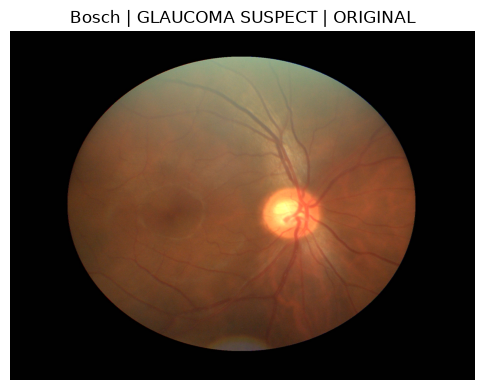

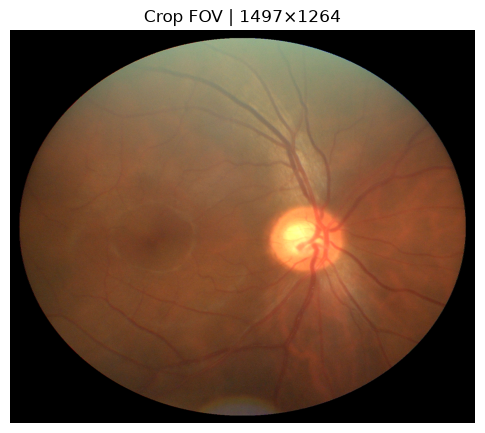

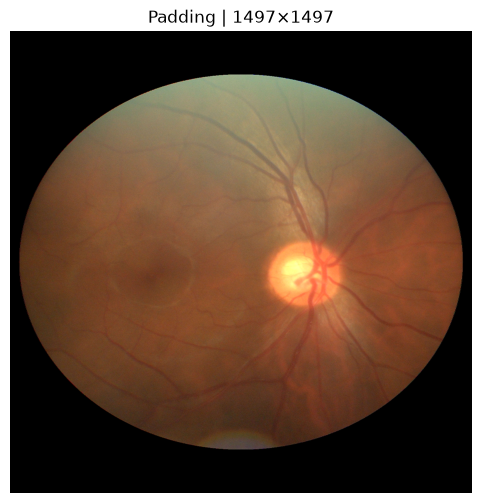

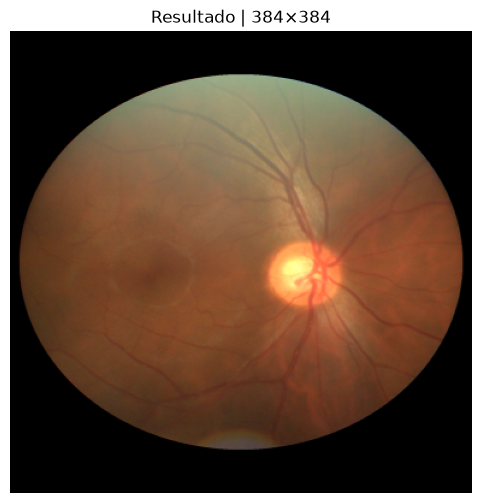

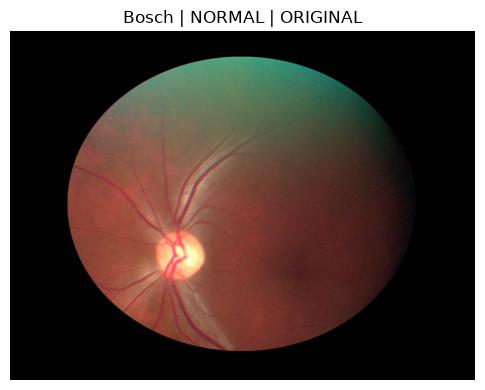

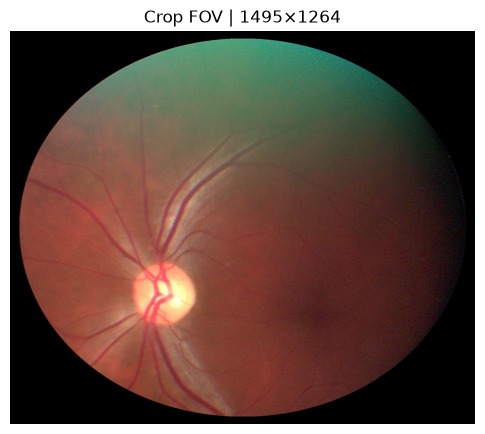

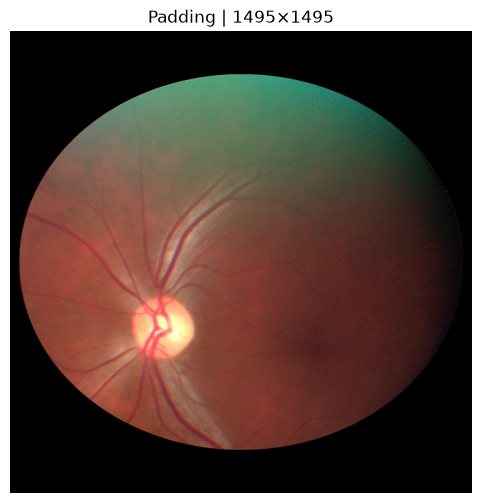

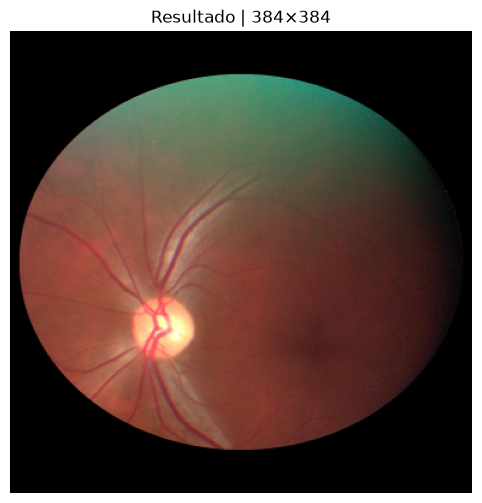

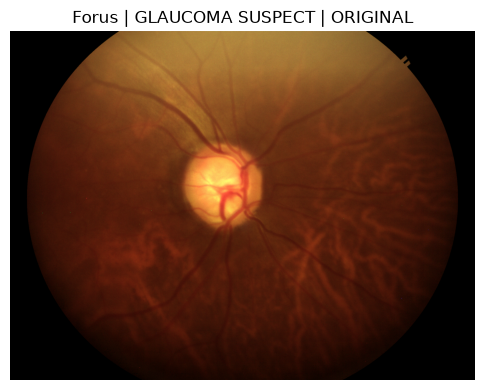

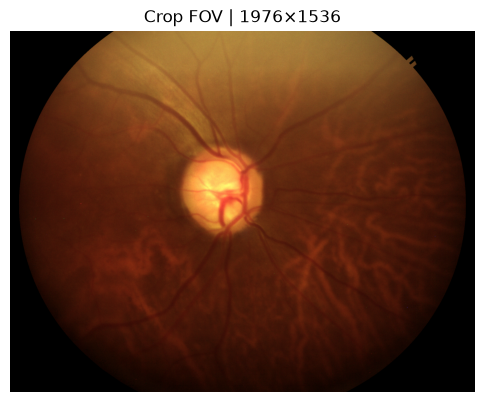

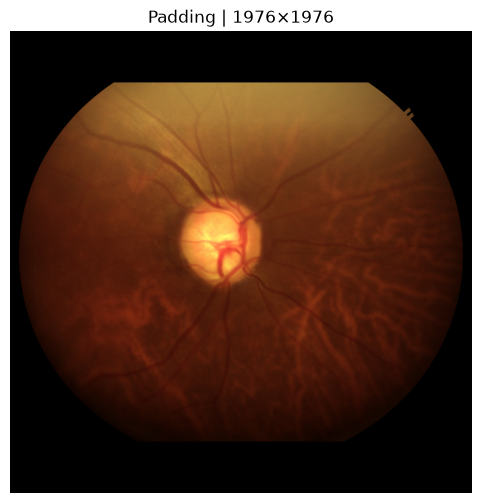

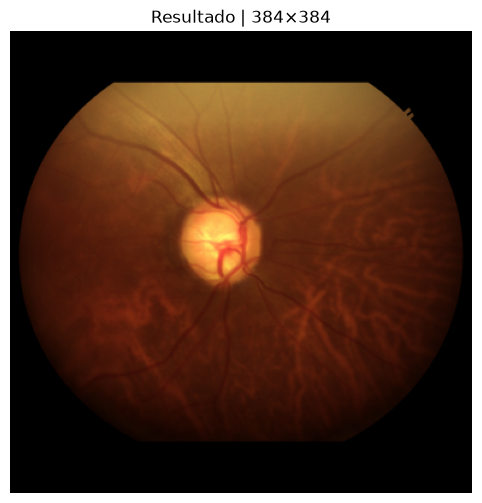

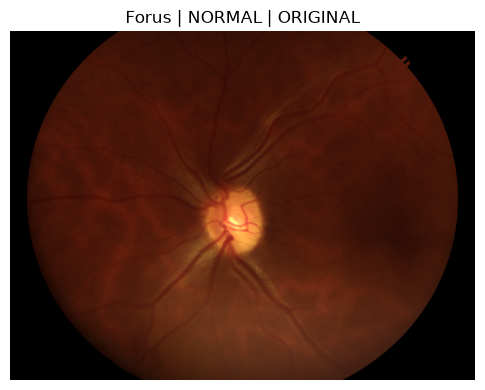

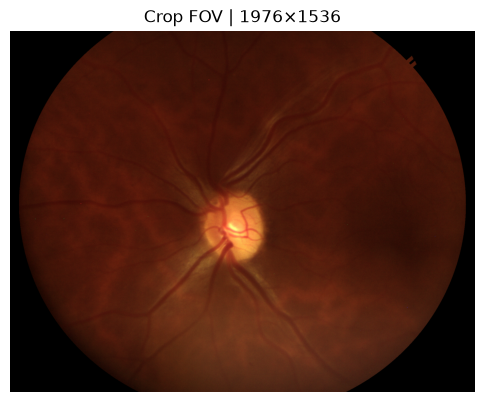

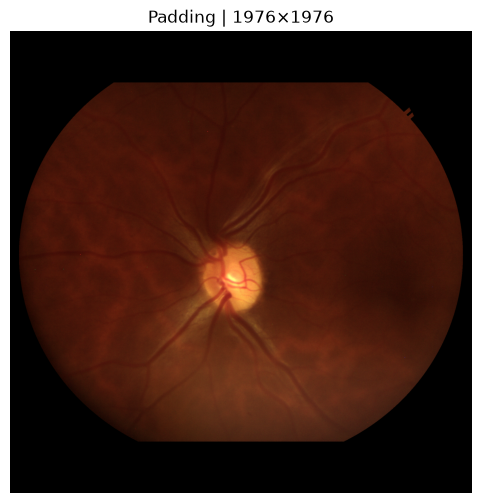

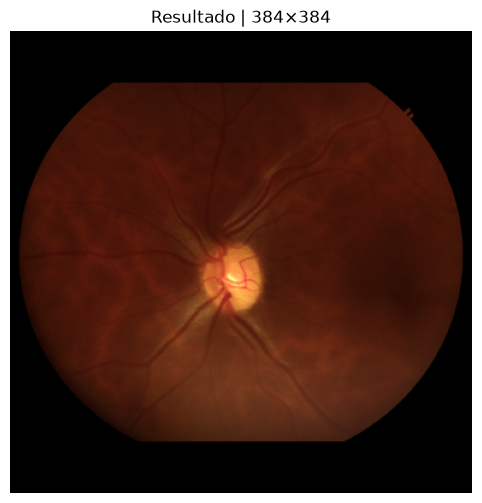

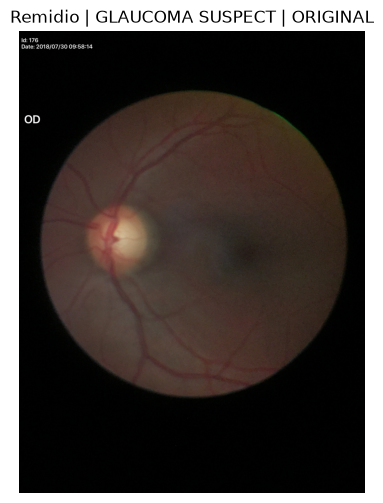

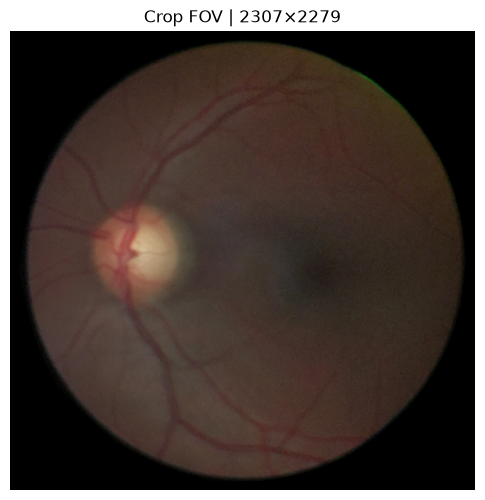

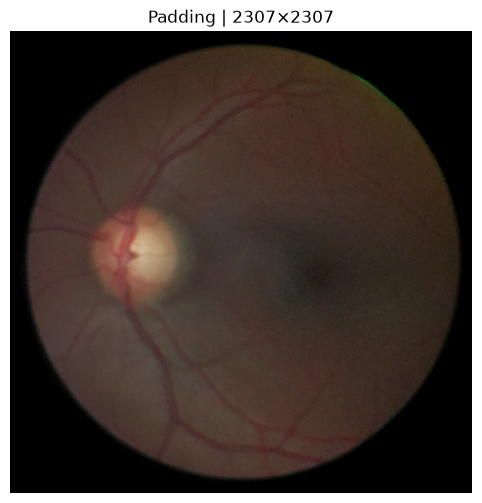

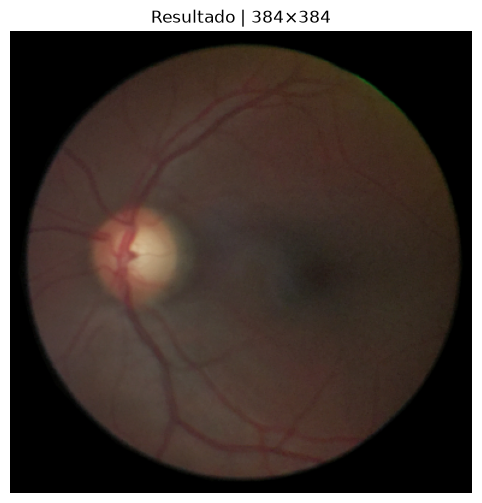

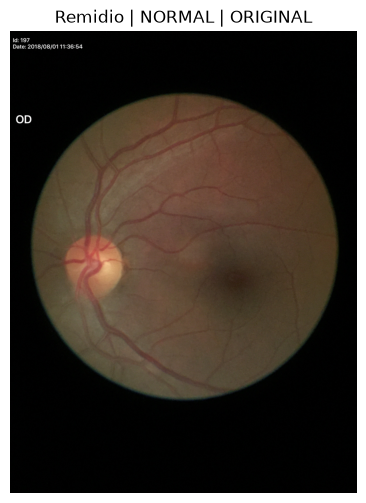

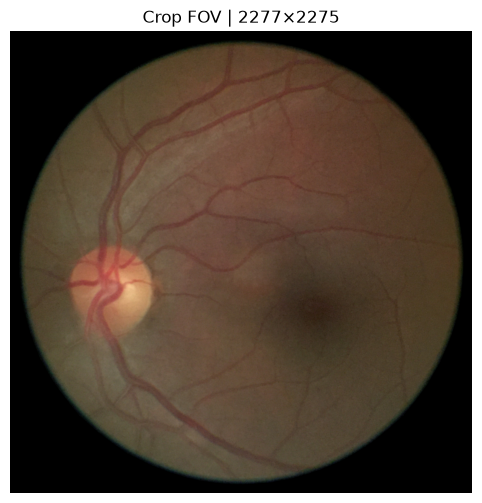

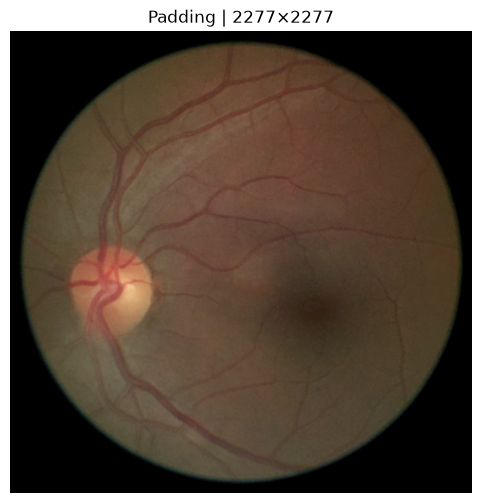

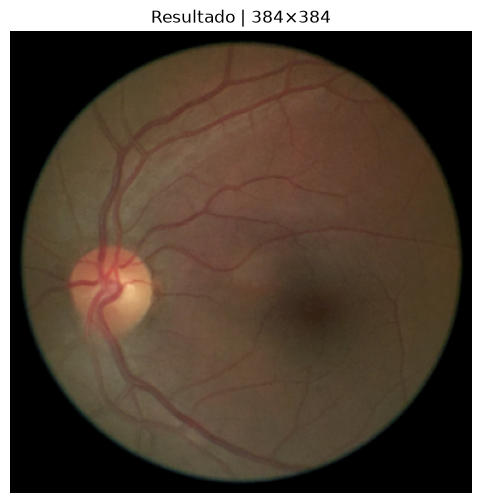

In [7]:
for _, fila in muestras.iterrows():
    ruta = resolver_ruta(
        fila["image_path"]
    )
    with Image.open(ruta) as img:
        original = np.array(
            img.convert("RGB")
        )
    crop, _ = recortar_fov(
        original
    )
    cuadrada = padding_cuadrado(
        crop
    )
    final = redimensionar_imagen(
        cuadrada
    )
    plt.figure(figsize=(6, 6))
    plt.imshow(original)
    plt.title(
        f"{fila['camera']} | {fila['original_label']} | ORIGINAL"
    )
    plt.axis("off")
    plt.show()

    plt.figure(figsize=(6, 6))
    plt.imshow(crop)
    plt.title(
        f"Crop FOV | {crop.shape[1]}×{crop.shape[0]}"
    )
    plt.axis("off")
    plt.show()

    plt.figure(figsize=(6, 6))
    plt.imshow(cuadrada)
    plt.title(
        f"Padding | {cuadrada.shape[1]}×{cuadrada.shape[0]}"
    )
    plt.axis("off")
    plt.show()

    plt.figure(figsize=(6, 6))
    plt.imshow(final)
    plt.title(
        f"Resultado | {final.shape[1]}×{final.shape[0]}"
    )
    plt.axis("off")
    plt.show()


## 8. Procesamiento sistemático de las 807 imágenes de Train

Se ejecuta el pipeline geométrico completo sobre la totalidad del subconjunto Train, evaluando la robustez numérica y la ausencia de fallos.

In [8]:
resultados_preprocesamiento = []
for _, fila in df_train.iterrows():
    ruta = resolver_ruta(
        fila["image_path"]
    )
    try:
        with Image.open(ruta) as img:
            imagen_rgb = np.array(
                img.convert("RGB")
            )
        procesada, bbox = preprocesar_geometria(
            imagen_rgb
        )
        resultados_preprocesamiento.append({
            "image_key": fila["image_key"],
            "camera": fila["camera"],
            "procesamiento_ok": True,
            "final_height": procesada.shape[0],
            "final_width": procesada.shape[1],
            "channels": procesada.shape[2],
            "error": None
        })
    except Exception as e:
        resultados_preprocesamiento.append({
            "image_key": fila["image_key"],
            "camera": fila["camera"],
            "procesamiento_ok": False,
            "final_height": None,
            "final_width": None,
            "channels": None,
            "error": str(e)
        })

preprocess_info = pd.DataFrame(
    resultados_preprocesamiento
)
print(
    "Train procesadas:",
    len(preprocess_info)
)
print(
    "Procesamientos fallidos:",
    (~preprocess_info["procesamiento_ok"])
    .sum()
)


Train procesadas: 807
Procesamientos fallidos: 0


## 9. Comprobación de dimensiones finales

Se verifica que la totalidad de las 807 imágenes procesadas converjan estrictamente a 384 × 384 píxeles con 3 canales RGB.

In [9]:
display(
    preprocess_info[
        [
            "final_width",
            "final_height",
            "channels"
        ]
    ]
    .value_counts()
    .reset_index(name="cantidad")
)


,final_width,final_height,channels,cantidad
0,384,384,3,807


# Conclusiones del preprocesamiento geométrico

Se implementó el pipeline geométrico de preprocesamiento definido a partir de
la exploración previa del dataset Chákṣu.

El procedimiento comprende:

1. Lectura de la retinografía en RGB.
2. Detección y enmascaramiento automático del campo de visión retinal.
3. Recorte del FOV con margen de seguridad.
4. Padding cuadrado para preservar la relación de aspecto.
5. Redimensionamiento final a 384 × 384 píxeles.

La validación se realizó exclusivamente sobre las 807 imágenes correspondientes
al subconjunto Train.

Las 807 imágenes fueron procesadas correctamente, sin errores, y todas
produjeron una salida uniforme de 384 × 384 × 3.

La inspección visual de las diferentes etapas mostró que el padding permite
preservar la geometría del campo retinal antes del redimensionamiento, evitando
un estiramiento directo de imágenes con diferentes relaciones de aspecto.

Las funciones de preprocesamiento geométrico quedan definidas para ser utilizadas
de manera consistente en los posteriores experimentos con ResNet50V2 y
EfficientNetV2-M.

En esta etapa no se aplicó Data Augmentation ni el preprocesamiento específico
de los backbones preentrenados.